# 02 · Ingeniería de features (leakage-safe) — Predictor UFC

Este notebook documenta **cómo** se transforman los datos crudos en las variables que ve el modelo, y **por qué** se hace con tanto cuidado.

**La regla de oro:** para predecir una pelea solo se puede usar información disponible *antes* de que ocurra. Usar estadísticas de dentro de la pelea (golpes, derribos) sería *fuga de datos* (**data leakage**): el modelo 'haría trampa' y su precisión sería una ilusión imposible de repetir en peleas futuras.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / 'config.py').exists():
    root = root.parent
sys.path.insert(0, str(root))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import config
from src.features.build_features import build_long, compute_prefight_features
plt.rcParams['figure.figsize'] = (9, 4); plt.rcParams['axes.grid'] = True


In [2]:
fights = pd.read_csv(config.FIGHTS_CSV, parse_dates=['date'])
stats = pd.read_csv(config.FIGHT_STATS_CSV)
fighters = pd.read_csv(config.FIGHTERS_CSV).set_index('fighter_id')
print('peleas:', len(fights), '| filas de stats:', len(stats), '| peleadores:', len(fighters))

peleas: 8772 | filas de stats: 17502 | peleadores: 2712


## 1. El problema, con un ejemplo
Tomamos al peleador con más peleas en el dataset. Su ficha en ufcstats trae estadísticas de carrera (SLpM, precisión…) que son **totales actuales**: ya incluyen *todas* sus peleas, también las que queremos predecir y las futuras. Por eso **no** podemos usarlas tal cual como features.

In [3]:
long = build_long(fights, stats)
fid = long.fighter_id.value_counts().index[0]
name = fighters.loc[fid, 'name']
print(f'Peleador de ejemplo: {name}  ({long.fighter_id.value_counts().loc[fid]} peleas)')
print('\nStats de carrera en su ficha (valores ACTUALES, acumulados de TODA su carrera):')
print(fighters.loc[fid, ['wins','losses','slpm','str_acc','td_avg']])

Peleador de ejemplo: Jim Miller  (47 peleas)

Stats de carrera en su ficha (valores ACTUALES, acumulados de TODA su carrera):
wins       39.00
losses     19.00
slpm        2.92
str_acc     0.42
td_avg      1.49
Name: d1941565abf50b16, dtype: float64


## 2. La solución: reconstrucción cronológica
Recorremos las peleas del peleador **en orden de fecha** y, para cada una, calculamos sus estadísticas usando **solo las peleas anteriores**. La 'tabla larga' tiene una fila por (pelea, peleador) con sus números y los del rival:

In [4]:
cols = ['date','won','method','minutes','sig_str_landed','sig_str_att','td_landed']
long[long.fighter_id == fid].sort_values('date')[cols].head(6)

,date,won,method,minutes,sig_str_landed,sig_str_att,td_landed
1952,2008-10-18,True,SUB,13.316667,15,28,5
2014,2008-12-10,True,DEC,15.000000,61,137,4
2153,2009-03-07,False,DEC,15.000000,25,100,0
2286,2009-07-11,True,DEC,15.000000,37,91,6
2360,2009-09-19,True,KO/TKO,5.800000,30,87,0
2502,2010-01-02,True,SUB,2.516667,6,23,0


Ahora calculamos las features **pre-pelea** (leakage-safe) y vemos cómo evolucionan a lo largo de la carrera del peleador. Nota que en su **debut** no hay historial: la experiencia es 0 y el % de victorias es indefinido (NaN).

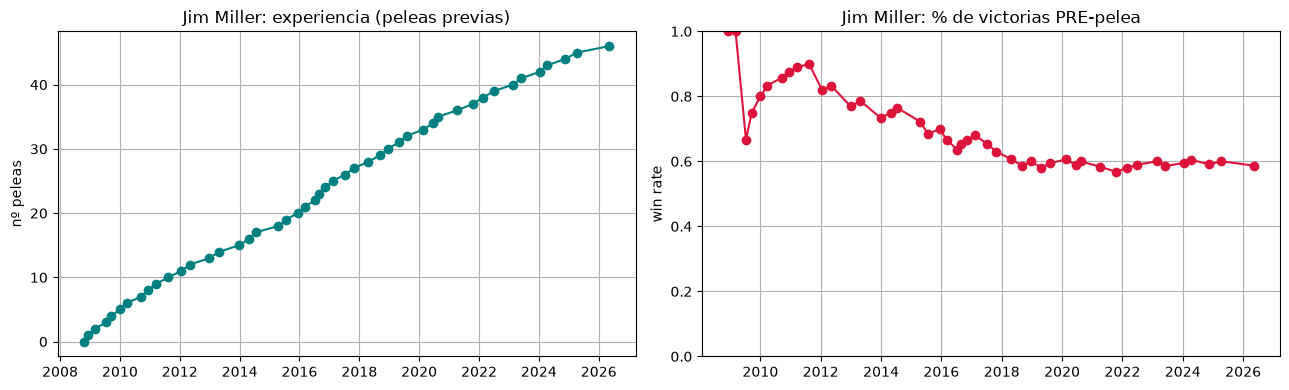

Primera pelea (debut) -> exp: 0 | win_rate: nan


In [5]:
pf = compute_prefight_features(long)
sub = long[long.fighter_id == fid].sort_values('date')
feats = pf.xs(fid, level='fighter_id')
hist = sub[['fight_id','date']].merge(feats, left_on='fight_id', right_index=True)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(hist['date'], hist['exp'], marker='o', color='teal')
ax[0].set_title(f'{name}: experiencia (peleas previas)'); ax[0].set_ylabel('nº peleas')
ax[1].plot(hist['date'], hist['win_rate'], marker='o', color='crimson')
ax[1].set_title(f'{name}: % de victorias PRE-pelea'); ax[1].set_ylabel('win rate'); ax[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()
print('Primera pelea (debut) -> exp:', hist.iloc[0]['exp'], '| win_rate:', hist.iloc[0]['win_rate'])

> Cada punto usa **únicamente** lo ocurrido antes de esa fecha. Ese es el corazón anti-leakage del proyecto (verificado en `tests/test_no_leakage.py`).

## 3. Diferencias (A − B) y simetría
El dataset final resta las features de los dos peleadores (`d_*` = A − B) y **duplica** cada pelea invirtiendo A/B y la etiqueta. Así el modelo aprende una función simétrica (no 'el que va primero gana'). Veamos las dos filas espejo de una misma pelea:

In [6]:
ds = pd.read_csv(config.DATASET_CSV)
some = ds[ds.fight_id == ds.fight_id.iloc[0]]
some[['fight_id','d_win_rate','d_reach_in','d_age','label']]

,fight_id,d_win_rate,d_reach_in,d_age,label
0,00835554f95fa911,NaN,NaN,-3.290897,1
1,00835554f95fa911,NaN,NaN,3.290897,0


Las diferencias de la segunda fila son exactamente las **negativas** de la primera, y la etiqueta está **invertida**. Por eso el balance de clases es 0.5 perfecto.

## 4. ¿Qué diferencias separan a ganadores de perdedores?
Correlación de cada feature-diferencia con la etiqueta (ganó A). Valores positivos: cuando A supera a B en esa estadística, tiende a ganar.

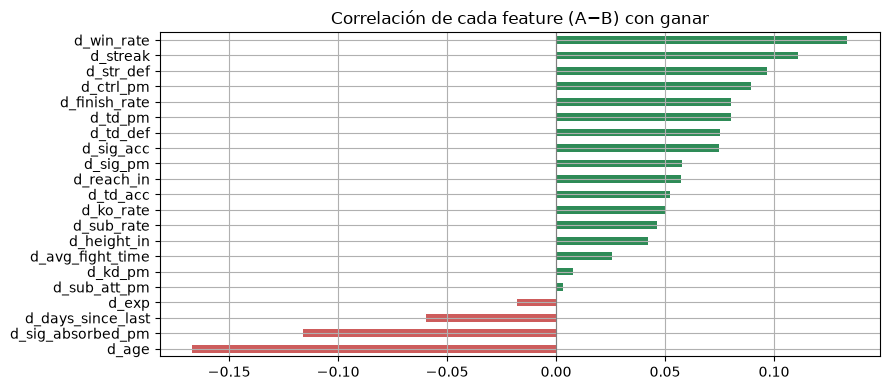

In [7]:
corr = ds.filter(like='d_').corrwith(ds['label']).sort_values()
corr.plot(kind='barh', color=(corr > 0).map({True: 'seagreen', False: 'indianred'}))
plt.title('Correlación de cada feature (A−B) con ganar'); plt.axvline(0, color='gray', lw=0.8)
plt.tight_layout(); plt.show()

## Conclusiones
- Las stats *dentro* de la pelea son **resultados**, no predictores → nunca se usan como features.
- Cada feature se reconstruye del **historial previo** de cada peleador (acumulador cronológico), lo que hace honesta la evaluación.
- El dataset usa **diferencias A−B** con **simetría** para no aprender sesgos de orden.
- Las features con más señal (racha, defensa, precisión, experiencia) son justamente las que un analista de MMA esperaría.